<a href="https://colab.research.google.com/github/MartaPCastillo/Tesis/blob/main/Liverpool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import yfinance as yf # Para descargar datos de acciones
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

#Liverpool

#Análisis de la serie de tiempo

In [2]:
#Obtener datos
df = yf.download('LIVEPOL1.MX', start='2024-01-01')

/tmp/ipykernel_3759/1046451472.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('LIVEPOL1.MX', start='2024-01-01')
[*********************100%***********************]  1 of 1 completed


In [16]:
print(type(df['Close']))

<class 'pandas.core.frame.DataFrame'>


In [17]:
# Eliminar nivel del ticker
df.columns = df.columns.droplevel(1)

##Medias Móviles

###Media Móvil Simple

In [25]:
#Calcular Media Móvil Simple de 200 días
df['SMA200'] = df['Close'].rolling(window=200).mean()

<Axes: xlabel='Date'>

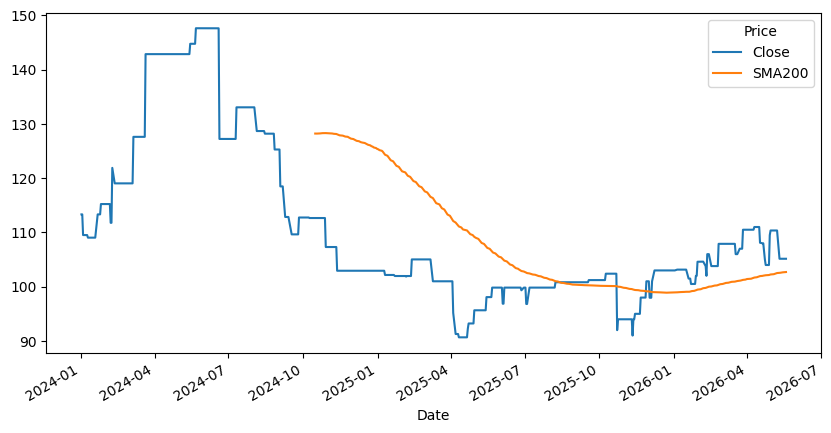

In [26]:
#Visualizar
df[['Close', 'SMA200']].plot(figsize=(10,5))

###Media Móvil Exponencial

In [27]:
#Calcular Media Móvil Exponencial de 200 días
df['EMA200'] = df['Close'].ewm(span=200, adjust=False).mean()

In [28]:
#Calcular Media Móvil Exponencial de 20 días
df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()

<Axes: xlabel='Date'>

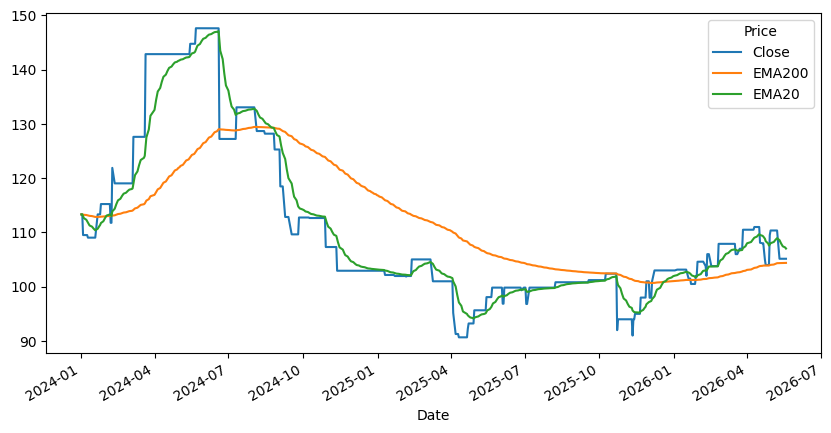

In [29]:
#Visualizar
df[['Close', 'EMA200', 'EMA20']].plot(figsize=(10,5))

##Descomposición Serie Temporal

###Modelo Aditivo

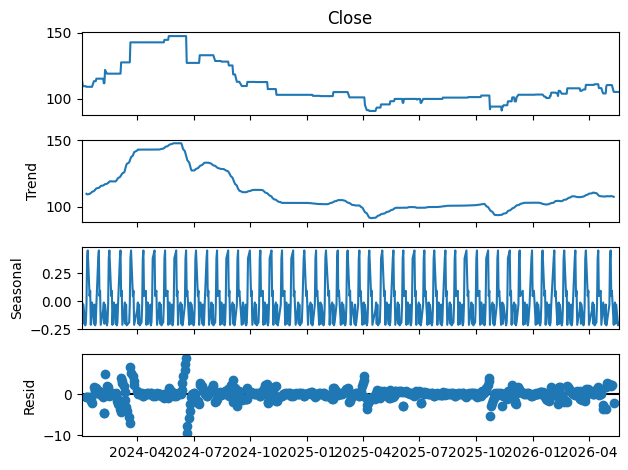

In [30]:
# Descomponer
result = seasonal_decompose(df['Close'], model='additive', period=12) # 12 meses en un año
result.plot()
plt.show()


###Modelo Multiplicativo

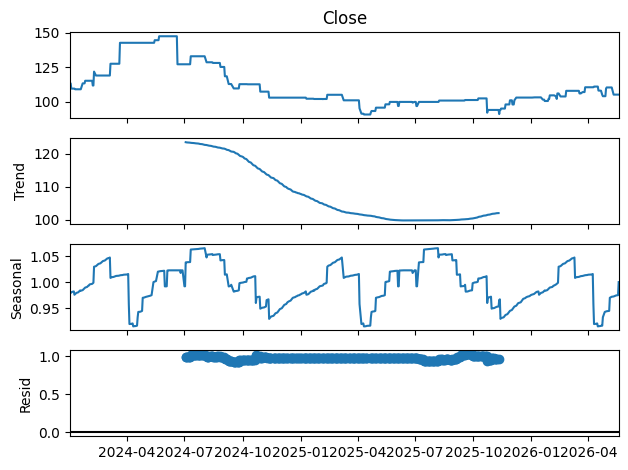

In [31]:
# Descomponer
result = seasonal_decompose(df['Close'], model='multiplicative', period=252) # 252 días hábiles en un año
result.plot()
plt.show()


#Volatilidad

##Desviación Estándar

In [42]:
#Obtener datos
precios = df['Close']
print(precios)

Date
2024-01-02    113.324379
2024-01-03    113.324379
2024-01-04    109.515160
2024-01-05    109.515160
2024-01-08    109.515160
                 ...    
2026-05-13    105.150002
2026-05-14    105.150002
2026-05-15    105.150002
2026-05-18    105.150002
2026-05-19    105.150002
Name: Close, Length: 594, dtype: float64


In [43]:
# Método financiero estándar para rendimientos logarítmicos
df['Rendimientos_Log'] = np.log(precios / precios.shift(1))
print(df['Rendimientos_Log'])

Date
2024-01-02         NaN
2024-01-03    0.000000
2024-01-04   -0.034191
2024-01-05    0.000000
2024-01-08    0.000000
                ...   
2026-05-13    0.000000
2026-05-14    0.000000
2026-05-15    0.000000
2026-05-18    0.000000
2026-05-19    0.000000
Name: Rendimientos_Log, Length: 594, dtype: float64


In [44]:
#Eliminar NaN solo de rendimientos
df.dropna(subset=['Rendimientos_Log'], inplace=True)
print(df['Rendimientos_Log'])

Date
2024-01-03    0.000000
2024-01-04   -0.034191
2024-01-05    0.000000
2024-01-08    0.000000
2024-01-09    0.000000
                ...   
2026-05-13    0.000000
2026-05-14    0.000000
2026-05-15    0.000000
2026-05-18    0.000000
2026-05-19    0.000000
Name: Rendimientos_Log, Length: 593, dtype: float64


In [48]:
#Calcular la desviación estándar de los rendimientos (Volatilidad Diaria)
volatilidad_diaria = df['Rendimientos_Log'].std()
Volatilidad_diaria_porcentaje = volatilidad_diaria * 100

In [49]:
#Anualizar la volatilidad (multiplicando por la raíz cuadrada de 252 días hábiles al año)
volatilidad_anual = volatilidad_diaria * np.sqrt(252)
Volatilidad_anual_porcentaje = volatilidad_anual * 100

In [50]:
print(f"Volatilidad diaria: {volatilidad_diaria:.4f} = {Volatilidad_diaria_porcentaje:.4f} %")
print(f"Volatilidad anualizada: {volatilidad_anual:.4f} = {Volatilidad_anual_porcentaje:.4f} %")

Volatilidad diaria: 0.0138 = 1.3764 %
Volatilidad anualizada: 0.2185 = 21.8489 %


#Average True Range (ATR)

In [51]:
#Calcular los 3 componentes del True Range (TR)
high_low = df['High'] - df['Low']
high_close = np.abs(df['High'] - df['Close'].shift(1))
low_close = np.abs(df['Low'] - df['Close'].shift(1))

In [52]:
print(high_low)

Date
2024-01-03    0.0
2024-01-04    0.0
2024-01-05    0.0
2024-01-08    0.0
2024-01-09    0.0
             ... 
2026-05-13    0.0
2026-05-14    0.0
2026-05-15    0.0
2026-05-18    0.0
2026-05-19    0.0
Length: 593, dtype: float64


In [53]:
print(high_close)

Date
2024-01-03         NaN
2024-01-04    3.809219
2024-01-05    0.000000
2024-01-08    0.000000
2024-01-09    0.000000
                ...   
2026-05-13    0.000000
2026-05-14    0.000000
2026-05-15    0.000000
2026-05-18    0.000000
2026-05-19    0.000000
Length: 593, dtype: float64


In [54]:
print(low_close)

Date
2024-01-03         NaN
2024-01-04    3.809219
2024-01-05    0.000000
2024-01-08    0.000000
2024-01-09    0.000000
                ...   
2026-05-13    0.000000
2026-05-14    0.000000
2026-05-15    0.000000
2026-05-18    0.000000
2026-05-19    0.000000
Length: 593, dtype: float64


In [55]:
#Unir y obtener el máximo de los 3 para cada día
ranges = pd.concat([high_low, high_close, low_close], axis=1)
true_range = ranges.max(axis=1)

In [56]:
print(true_range)

Date
2024-01-03    0.000000
2024-01-04    3.809219
2024-01-05    0.000000
2024-01-08    0.000000
2024-01-09    0.000000
                ...   
2026-05-13    0.000000
2026-05-14    0.000000
2026-05-15    0.000000
2026-05-18    0.000000
2026-05-19    0.000000
Length: 593, dtype: float64


In [57]:
#Calcular el ATR (suavizado clásico de Wilder, n=14)
atr_period = 14
atr = true_range.copy()

In [58]:
#El primer ATR es la media simple de los primeros 14 días
atr.iloc[atr_period-1] = true_range.iloc[:atr_period].mean()

In [59]:
#Iterar para aplicar la fórmula suavizada
for i in range(atr_period, len(true_range)):
    atr.iloc[i] = (atr.iloc[i-1] * (atr_period - 1) + true_range.iloc[i]) / atr_period

df['ATR_Calculado'] = atr
print(df[['High', 'Low', 'Close', 'ATR_Calculado']].tail())

Price             High         Low       Close  ATR_Calculado
Date                                                         
2026-05-13  105.150002  105.150002  105.150002       0.923473
2026-05-14  105.150002  105.150002  105.150002       0.857511
2026-05-15  105.150002  105.150002  105.150002       0.796260
2026-05-18  105.150002  105.150002  105.150002       0.739384
2026-05-19  105.150002  105.150002  105.150002       0.686571


In [60]:
#ATR diario
atr_diario = atr.mean()
print(f"ATR diario: {atr_diario:.4f}")

ATR diario: 0.4285


In [61]:
#ATR Anualizado
atr_anualizado = atr.mean() * np.sqrt(252)
print(f"ATR anualizado: {atr_anualizado:.4f}")

ATR anualizado: 6.8025


#Serie Estacionaria


In [32]:
#Obtener datos
precios = df['Close']

In [33]:
# Transformación a retornos porcentuales (diferenciación)
# Los precios suelen ser no estacionarios, los retornos sí lo son.
retornos = precios.pct_change().dropna()

In [34]:
# Función para realizar la prueba de Dickey-Fuller Aumentada
def probar_estacionariedad(serie, titulo):
    print(f"\n--- Prueba ADF para: {titulo} ---")
    resultado = adfuller(serie.dropna())
    estadistico = resultado[0]
    valor_p = resultado[1]
    criticos = resultado[4]

    print(f"Estadístico de Dickey-Fuller: {estadistico:.4f}")
    print(f"Valor p: {valor_p:.4f}")

    if valor_p < 0.05:
        print("Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).")
    else:
        print("Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).")

    return valor_p

In [35]:
# Ejecutar prueba en Precios (Original)
probar_estacionariedad(precios, "Precios de Cierre (Original)")


--- Prueba ADF para: Precios de Cierre (Original) ---
Estadístico de Dickey-Fuller: -1.2944
Valor p: 0.6317
Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).


np.float64(0.631731388908485)

In [36]:
# Ejecutar prueba en Retornos (Transformados)
probar_estacionariedad(retornos, "Retornos Porcentuales")


--- Prueba ADF para: Retornos Porcentuales ---
Estadístico de Dickey-Fuller: -24.7559
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

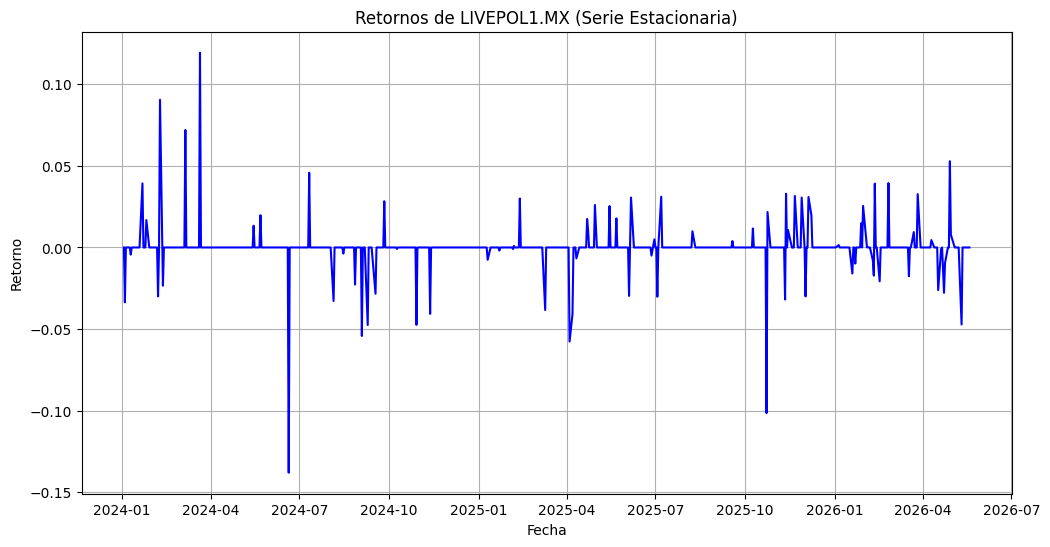

In [37]:
# Visualización
plt.figure(figsize=(12, 6))
plt.plot(retornos, label=f'Retornos de {'LIVEPOL1.MX'}', color='blue')
plt.title(f'Retornos de {'LIVEPOL1.MX'} (Serie Estacionaria)')
plt.xlabel('Fecha')
plt.ylabel('Retorno')
plt.grid(True)
plt.show()

##Diferenciando para hacer estacionaria la serie

Head of the differenced price series:
Date
2024-01-03    0.000000
2024-01-04   -3.809219
2024-01-05    0.000000
2024-01-08    0.000000
2024-01-09    0.000000
Name: Close, dtype: float64


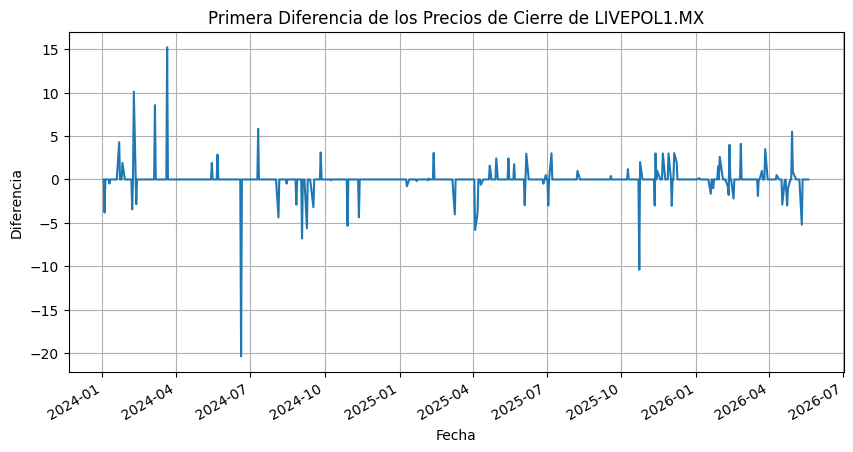

In [38]:
# Calcular la primera diferencia del precio de cierre (columna 'Close')
differenced_prices = df['Close'].diff().dropna()

# Mostrar los primeros elementos de la serie diferenciada
print("Head of the differenced price series:")
print(differenced_prices.head())

# Visualizar la serie diferenciada
plt.figure(figsize=(10,5))
differenced_prices.plot()
plt.title(f'Primera Diferencia de los Precios de Cierre de {"LIVEPOL1.MX"}')
plt.xlabel('Fecha')
plt.ylabel('Diferencia')
plt.grid(True)
plt.show()

In [39]:
# Ejecutar prueba en serie diferenciada
probar_estacionariedad(differenced_prices, "Serie diferenciada")


--- Prueba ADF para: Serie diferenciada ---
Estadístico de Dickey-Fuller: -24.7083
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0